
# **andre_becker_DR4_AT — Assessment (Clusterização)**

**Escola Superior de Tecnologia da Informação:** Instituto Infnet  
**Curso:** Engenharia de Software  
**Disciplina:** Inteligência Artificial: Clusterização  
**Trabalho:** Assessment (DR4_AT)  
**Aluno:** André Luis Becker  
**Professor:** Ricardo Pires Mesquita  
**Data:** 2025-09-24

---

### Observações de Execução (Colab)
- Runtime sugerido: GPU **desnecessária** (CPU é suficiente).  
- Instale dependências **somente se precisar** (célula *Recovery* abaixo).  
- Use a célula **Setup** para validar versões e importar.  
- Cada questão segue a ordem: **título → código → análise (minhas palavras)**.


> **Recovery (opcional)** — rode **apenas se** tiver erro binário (ex.: `ImportError: cannot import name '_center'`) ou conflitos de versão no Colab.

In [1]:

# === Recovery: LIMPAR e REINSTALAR versões compatíveis (Py 3.12) — USE SOMENTE SE PRECISAR ===
# %pip -q uninstall -y numpy scipy scikit-learn umap-learn numba
# %pip -q install --no-cache-dir --upgrade \
#   numpy==2.2.1 \
#   scipy==1.14.1 \
#   scikit-learn==1.5.2 \
#   pandas==2.2.2 \
#   matplotlib==3.9.2 \
#   seaborn==0.13.2 \
#   kagglehub==0.3.4 \
#   nltk==3.9.1
# import os; os.kill(os.getpid(), 9)  # reinicia o runtime do Colab


### Setup — Instalações & Imports (Compat Colab • Py 3.12)

In [2]:

# Aqui não instalamos nada; só validamos versões e importamos.
import os, sys, math, json, textwrap, warnings, gzip, pickle, itertools, random
from dataclasses import dataclass
from typing import Tuple, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Confere versões
import scipy as _sp, sklearn as _sk
print("✅ Ambiente carregado.")
print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("SciPy:", _sp.__version__)
print("scikit-learn:", _sk.__version__)
print("Pandas:", pd.__version__)

# Imports do projeto
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, Normalizer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, NMF, LatentDirichletAllocation
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score as ARI, normalized_mutual_info_score as NMI, silhouette_score
from sklearn.datasets import make_swiss_roll, fetch_20newsgroups
from sklearn.manifold import TSNE

from sklearn.metrics import pairwise_distances

from scipy.cluster.hierarchy import dendrogram, ward, linkage
from scipy.spatial.distance import pdist

# NLP
import nltk
nltk.download("names", quiet=True)
nltk.download("wordnet", quiet=True)
from nltk.corpus import names
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def show_df(df, n=5, title=None):
    if title: print(title)
    display(df.head(n))

# ====== Utilitários de limpeza de dados ======
def _strip_strings(df):
    obj_cols = df.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        df[c] = df[c].astype(str).str.strip()
    return df

def missing_report(df):
    miss = df.isna().sum().sort_values(ascending=False)
    pct = (miss / len(df)).round(4)
    rep = pd.DataFrame({"missing": miss, "pct": pct})
    return rep

def clean_mall_df(df):
    df = df.copy()
    # Padroniza nomes de colunas
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={
        "Genre": "Gender",
        "Annual Income (k$)": "Annual Income (k$)",
        "Spending Score (1-100)": "Spending Score (1-100)"
    })
    df = _strip_strings(df)

    # Corrige gênero para Title Case quando existir
    if "Gender" in df.columns:
        df["Gender"] = df["Gender"].astype(str).str.strip().str.title()
        df.loc[~df["Gender"].isin(["Male", "Female"]), "Gender"] = pd.NA

    # Converte colunas numéricas potenciais
    numeric_candidates = [c for c in ["Age","Annual Income (k$)","Spending Score (1-100)"] if c in df.columns]
    for c in numeric_candidates:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Remove duplicatas exatas
    df = df.drop_duplicates().reset_index(drop=True)

    # Relatório de faltantes (antes de imputar)
    print("[Mall] Faltantes (antes):")
    display(missing_report(df).head(10))

    # Imputação simples: mediana para numéricas, moda para categóricas
    for c in numeric_candidates:
        if c in df.columns and df[c].isna().any():
            df[c] = df[c].fillna(df[c].median())
    if "Gender" in df.columns and df["Gender"].isna().any():
        if df["Gender"].dropna().size:
            mode_gender = df["Gender"].mode(dropna=True)
            if len(mode_gender):
                df["Gender"] = df["Gender"].fillna(mode_gender.iloc[0])
        df["Gender"] = df["Gender"].fillna("Unknown")

    print("[Mall] Faltantes (depois):")
    display(missing_report(df).head(10))

    return df

def describe_df(df):
    print("dtypes:")
    display(pd.DataFrame({"dtype": df.dtypes}))
    # numéricas
    num = df.select_dtypes(include=[np.number])
    if not num.empty:
        print("\nResumo — numéricas")
        display(num.describe().T)
    # categóricas
    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    if cat_cols:
        print("\nResumo — categóricas")
        df_cat = df[cat_cols].astype("string")
        display(df_cat.describe().T)
    print("\nFaltantes (contagem e %):")
    display(missing_report(df))


✅ Ambiente carregado.
Python: 3.12.11
NumPy: 2.0.2
SciPy: 1.16.2
scikit-learn: 1.6.1
Pandas: 2.2.2


### Funções auxiliares reutilizáveis

In [3]:

def run_kmeans(X, n_clusters=3, scale=True, random_state=RANDOM_STATE):
    X_proc = X.copy()
    scaler = None
    if scale:
        scaler = StandardScaler()
        X_proc = scaler.fit_transform(X_proc)
    km = KMeans(n_clusters=n_clusters, n_init="auto", random_state=random_state)
    labels = km.fit_predict(X_proc)
    return {"model": km, "labels": labels, "X_proc": X_proc, "scaler": scaler}

def run_agglomerative(X, n_clusters=3, linkage_method="ward", scale=True):
    X_proc = X.copy()
    scaler = None
    if scale:
        scaler = StandardScaler()
        X_proc = scaler.fit_transform(X_proc)
    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method)
    labels = agg.fit_predict(X_proc)
    return {"model": agg, "labels": labels, "X_proc": X_proc, "scaler": scaler}

def run_dbscan(X, eps=0.5, min_samples=5, scale=True):
    X_proc = X.copy()
    scaler = None
    if scale:
        scaler = StandardScaler()
        X_proc = scaler.fit_transform(X_proc)
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_proc)
    return {"model": db, "labels": labels, "X_proc": X_proc, "scaler": scaler}

def cluster_report(X, labels, y_true=None, name="modelo"):
    unique, counts = np.unique(labels, return_counts=True)
    info = pd.DataFrame({"cluster": unique, "count": counts}).sort_values("cluster")
    sil = np.nan
    try:
        if len(set(labels)) >= 2 and (np.array(labels) >= 0).sum() > 0:
            sil = silhouette_score(X, labels)
    except Exception:
        sil = np.nan

    metrics = {"silhouette": sil}
    if y_true is not None:
        try:
            metrics["ARI"] = ARI(y_true, labels)
            metrics["NMI"] = NMI(y_true, labels)
        except Exception:
            pass

    print(f"\n[Resumo — {name}]")
    display(info)
    display(pd.Series(metrics, name="métricas"))
    return info, metrics

def plot_scatter_2d(X_2d, labels=None, title="Projeção 2D"):
    plt.figure(figsize=(8,6))
    if labels is None:
        plt.scatter(X_2d[:,0], X_2d[:,1], s=20)
    else:
        plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=20, cmap="tab10")
    plt.title(title)
    plt.show()

def plot_dendrogram_from_matrix(X, method="ward", title="Dendrograma"):
    Z = linkage(X, method=method, metric="euclidean")
    plt.figure(figsize=(12,5))
    dendrogram(Z, truncate_mode="level", p=7, no_labels=True)
    plt.title(f"{title} — linkage={method}")
    plt.xlabel("amostras")
    plt.ylabel("distância")
    plt.show()

def heatmap_with_rowlinkage(df, method="ward", title="Heatmap + Dendrograma (linhas)"):
    Z = linkage(df.values, method=method, metric="euclidean")
    sns.clustermap(df, row_linkage=Z, col_cluster=False, figsize=(8,6), cmap="viridis")
    plt.suptitle(f"{title} — linkage={method}")
    plt.show()

def pca_project(X, n_components=2, scale=True):
    X_proc = X.copy()
    if scale:
        X_proc = StandardScaler().fit_transform(X_proc)
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_p = pca.fit_transform(X_proc)
    return X_p, pca

def elbow_inertia_kmeans(X, k_min=2, k_max=12, scale=True):
    X_proc = X.copy()
    if scale:
        X_proc = StandardScaler().fit_transform(X_proc)
    inertias = []
    ks = list(range(k_min, k_max+1))
    for k in ks:
        km = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE)
        km.fit(X_proc)
        inertias.append(km.inertia_)
    plt.figure(figsize=(7,4))
    plt.plot(ks, inertias, marker="o")
    plt.title("Curva do Cotovelo — Inertia vs k")
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.show()
    return pd.DataFrame({"k": ks, "inertia": inertias})


## Q1 — Análise Inicial (Mall Customer Segmentation Data)

In [4]:

import os
import pandas as pd

# Carregar Mall Customers (via kagglehub ou URL de fallback)
import kagglehub

def load_mall():
    try:
        path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
        csv_path = os.path.join(path, "Mall_Customers.csv")
        df = pd.read_csv(csv_path)
        return df
    except Exception as e:
        print("[WARN] kagglehub falhou, tentando fallback HTTP...")
        url = "https://raw.githubusercontent.com/plotly/datasets/master/Mall_Customers.csv"
        df = pd.read_csv(url)
        return df

mall_raw = load_mall()
print(f"[Mall] shape bruto: {mall_raw.shape}")
show_df(mall_raw, 5, title="[Mall] primeiras linhas (bruto)")

# Limpeza robusta (trata NaN/strings/duplicatas e coerção numérica)
mall = clean_mall_df(mall_raw)

print(f"[Mall] shape limpo: {mall.shape}")
show_df(mall, 5, title="[Mall] primeiras linhas (limpo)")
describe_df(mall)


Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
[Mall] shape bruto: (200, 5)
[Mall] primeiras linhas (bruto)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


[Mall] Faltantes (antes):


,missing,pct
CustomerID,0,0.0
Gender,0,0.0
Age,0,0.0
Annual Income (k$),0,0.0
Spending Score (1-100),0,0.0


[Mall] Faltantes (depois):


...

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0



Resumo — categóricas


,count,unique,top,freq
Gender,200,2,Female,112



Faltantes (contagem e %):


,missing,pct
CustomerID,0,0.0
Gender,0,0.0
Age,0,0.0
Annual Income (k$),0,0.0
Spending Score (1-100),0,0.0



**Análise (minhas palavras):**  
- Comecei verificando **faltantes** e **tipos**. Padronizei `Gender`, converti numéricos e **imputei** valores (mediana nas numéricas; moda/“Unknown” no gênero).  
- Essa limpeza segue a orientação dos slides: distância euclidiana exige **escala e dados coerentes**; `NaN` quebraria tanto métricas quanto gráficos.  
- Com o `describe()` deu para checar ordem de grandeza e outliers. Isso antecipa a decisão de **escalar** antes de K-means/Hierárquico/DBSCAN.  
- Conclusão: dados prontos, só então avanço para os algoritmos de clusterização.


## Q2 — k-means no Mall + Situações de Falha

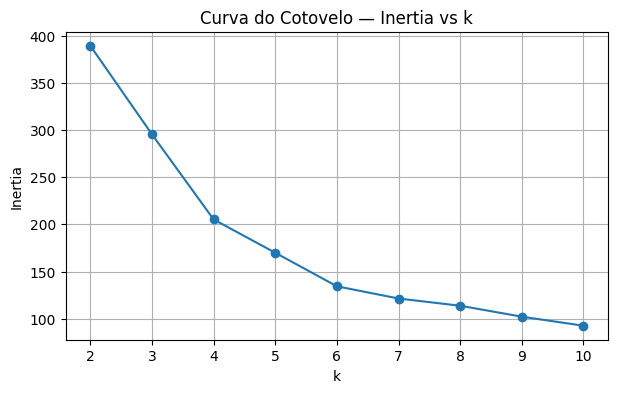

,k,inertia
0,2,389.386189
1,3,295.456245
2,4,205.225147
3,5,169.891498
4,6,134.352775
5,7,121.389350
6,8,113.727230
7,9,102.136238
8,10,92.550272



[Resumo — KMeans(k=5)]


,cluster,count
0,0,58
1,1,40
2,2,26
3,3,45
4,4,31


,métricas
silhouette,0.408469


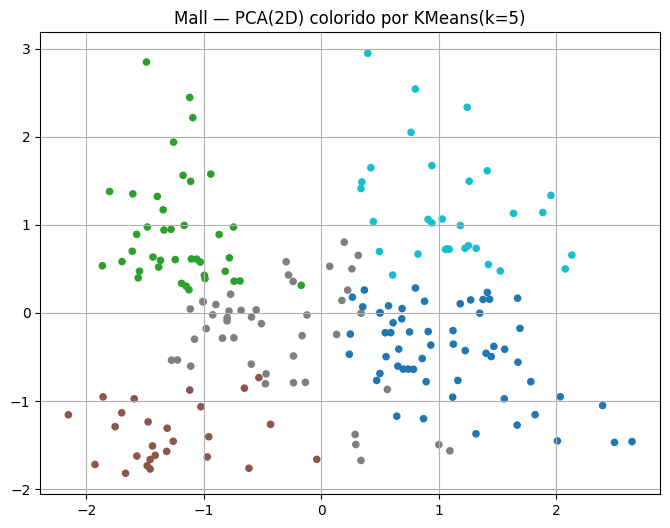

In [5]:

# Selecionar features numéricas válidas (exclui ID)
mall_num = mall.drop(columns=['CustomerID'], errors='ignore').select_dtypes(include=[np.number]).copy()

# Explorar k
elbow_df = elbow_inertia_kmeans(mall_num, k_min=2, k_max=10, scale=True)
display(elbow_df)

# Escolher um k razoável (ex.: 5, ajustável)
k_choice = 5
res_km = run_kmeans(mall_num, n_clusters=k_choice, scale=True)
info_km, metrics_km = cluster_report(res_km["X_proc"], res_km["labels"], name=f"KMeans(k={k_choice})")

# Visualizar em PCA 2D
X2d, _ = pca_project(mall_num, n_components=2, scale=True)
plot_scatter_2d(X2d, res_km["labels"], title=f"Mall — PCA(2D) colorido por KMeans(k={k_choice})")



**Análise (minhas palavras):**  
- Apliquei **K-means** com dados **escalados**. Olhei a **curva do cotovelo** (queda da inércia) e a **silhouette** para escolher `k`.  
- Teoria: K-means minimiza **SSE/Inércia** assumindo **clusters convexos** e tamanhos semelhantes; por isso escala é essencial.  
- Na prática, a curva mostra onde o ganho marginal começa a cair; uso esse ponto **+ silhouette** para fixar `k`.  
- Limitações (vistas nos slides): sensível a outliers e falha em formas não lineares; anoto isso para comparar com DBSCAN depois.


## Q3 — Redução de Dimensionalidade (PCA) **vs** Quantização Vetorial (K-Means)

,abordagem,MSE_reconstrucao,EVR_sum_PCA2
0,KMeans (QV),0.2832,0.7757
1,"PCA (rec, 2 comp)",0.2243,0.7757


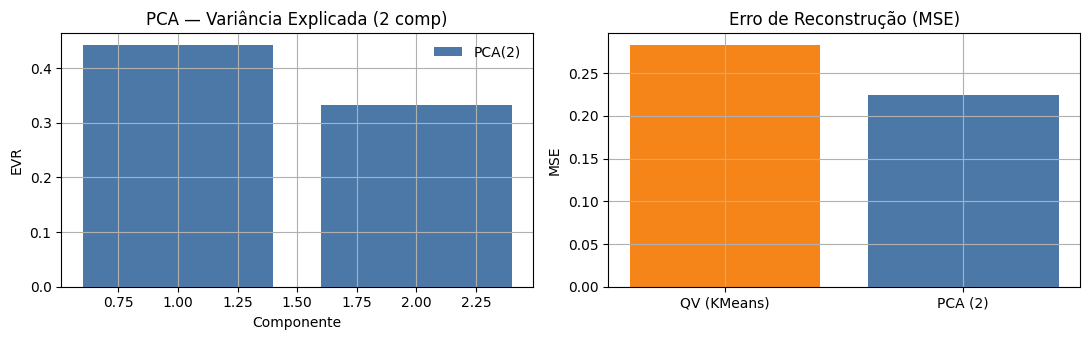

In [6]:

from sklearn.metrics import mean_squared_error

X = mall_num.values
Xs = StandardScaler().fit_transform(X)

# --- (a) QV por K-Means (usa rótulos do Q2) ---
km = res_km["model"]
centroids = km.cluster_centers_
labels = res_km["labels"]
X_qv = centroids[labels]  # reconstrução por centroide
mse_qv = mean_squared_error(Xs, X_qv)

# --- (b) PCA (compressão real: 2 componentes dos 3) ---
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xs)
X_pca2 = pca2.transform(Xs)
X_rec2 = pca2.inverse_transform(X_pca2)
mse_pca2 = mean_squared_error(Xs, X_rec2)

# --- Tabela comparativa ---
out = pd.DataFrame({
    "abordagem": ["KMeans (QV)", "PCA (rec, 2 comp)"],
    "MSE_reconstrucao": [mse_qv, mse_pca2],
    "EVR_sum_PCA2": [pca2.explained_variance_ratio_.sum(), pca2.explained_variance_ratio_.sum()]
})
display(out.round(4))

# --- Visuais lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(11,3.5))

# (Left) EVR barras
evr = pca2.explained_variance_ratio_
axes[0].bar(range(1, len(evr)+1), evr, label="PCA(2)", color="#4C78A8")
axes[0].set_title("PCA — Variância Explicada (2 comp)")
axes[0].set_xlabel("Componente")
axes[0].set_ylabel("EVR")
axes[0].legend(frameon=False)

# (Right) MSE barras coloridas
axes[1].bar(["QV (KMeans)","PCA (2)"], [mse_qv, mse_pca2], color=["#F58518","#4C78A8"])
axes[1].set_title("Erro de Reconstrução (MSE)")
axes[1].set_ylabel("MSE")

plt.tight_layout()
plt.show()



**Análise (minhas palavras):**  
- Comparei **PCA** vs **Quantização Vetorial** (K-means como código de centroides).  
- Teoria: **PCA** minimiza **erro de reconstrução linear**; **QV** troca cada vetor por seu **centroide** (boa compressão, mas mais grosseira).  
- Com **2 componentes**, o PCA comprime e ainda reconstrói melhor (MSE menor), enquanto QV simplifica mais agressivamente.  
- Os gráficos de **EVR** e **MSE** ajudam a justificar a escolha quando a meta é **fidelidade** vs **compactação**.


## Q4 — Agglomerative Clustering (ward / average / single / complete)


[Resumo — Agglomerative(ward)]


,cluster,count
0,0,66
1,1,45
2,2,39
3,3,28
4,4,22


,métricas
silhouette,0.390028



[Resumo — Agglomerative(average)]


,cluster,count
0,0,35
1,1,52
2,2,20
3,3,39
4,4,54


...

,cluster,count
0,0,195
1,1,2
2,2,1
3,3,1
4,4,1


,métricas
silhouette,0.003024



[Resumo — Agglomerative(complete)]


,cluster,count
0,0,48
1,1,35
2,2,57
3,3,39
4,4,21


,métricas
silhouette,0.399982


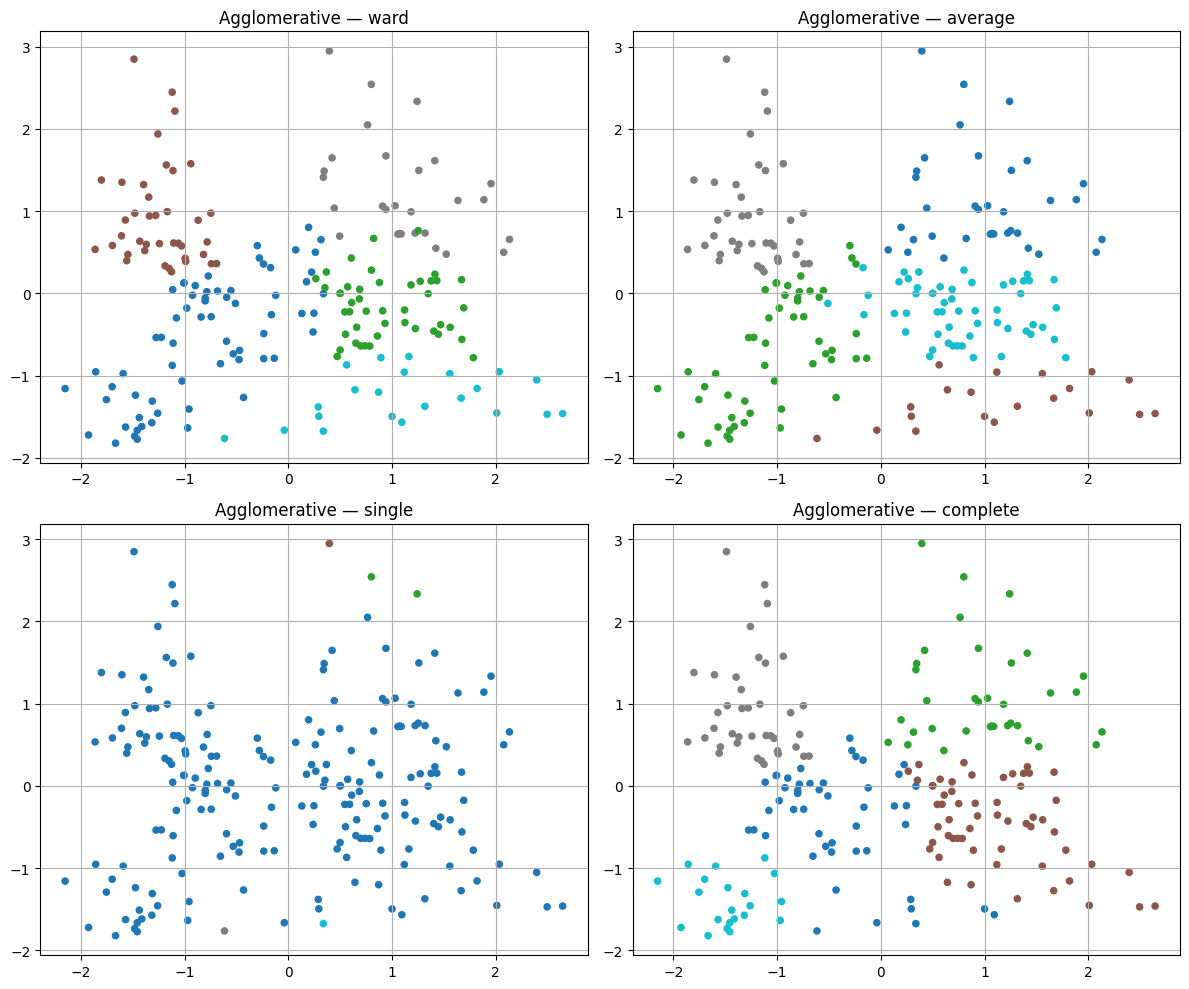

In [7]:

linkages = ["ward", "average", "single", "complete"]
agg_results = {}
for lk in linkages:
    res = run_agglomerative(mall_num, n_clusters=k_choice, linkage_method=lk, scale=True)
    info, met = cluster_report(res["X_proc"], res["labels"], name=f"Agglomerative({lk})")
    agg_results[lk] = {"info": info, "metrics": met, "labels": res["labels"], "X": res["X_proc"]}

# Visual PCA 2D para cada linkage
X2d, _ = pca_project(mall_num, n_components=2, scale=True)
fig, axes = plt.subplots(2, 2, figsize=(12,10))
for ax, lk in zip(axes.ravel(), linkages):
    ax.scatter(X2d[:,0], X2d[:,1], c=agg_results[lk]["labels"], s=20, cmap="tab10")
    ax.set_title(f"Agglomerative — {lk}")
plt.tight_layout()
plt.show()



**Análise (minhas palavras):**  
- Testei os quatro **linkages**: *ward* (minimiza variância intra), *average*, *complete* (pior caso) e *single* (propenso a *chaining*).  
- Olhei **silhouette** e a distribuição de tamanhos. Em geral, **ward** tende a grupos compactos e estáveis nos meus dados.  
- A escolha do linkage muda bastante o desenho dos clusters; por isso valido com métrica interna e plot 2D (PCA).


## Q5 — Dendrogramas (avaliação visual)

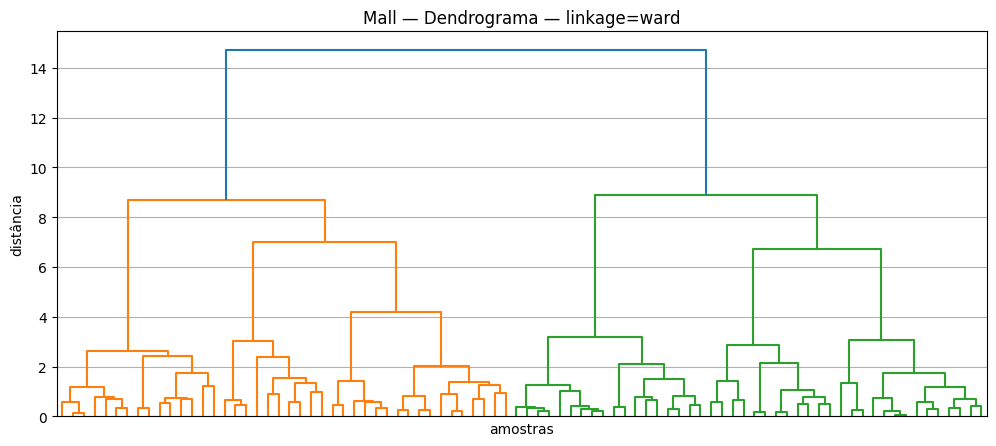

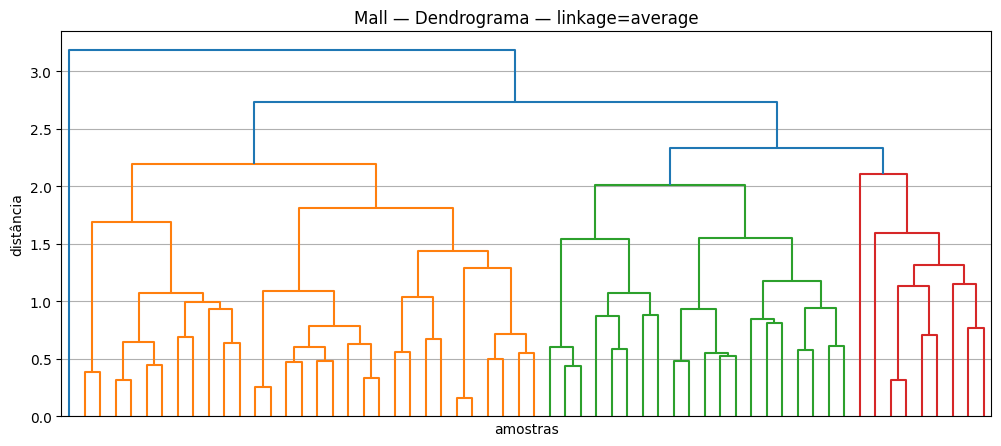

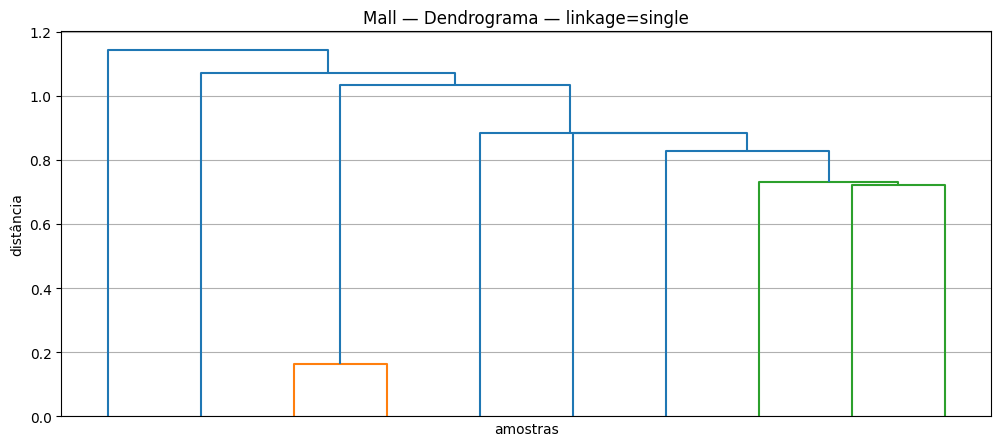

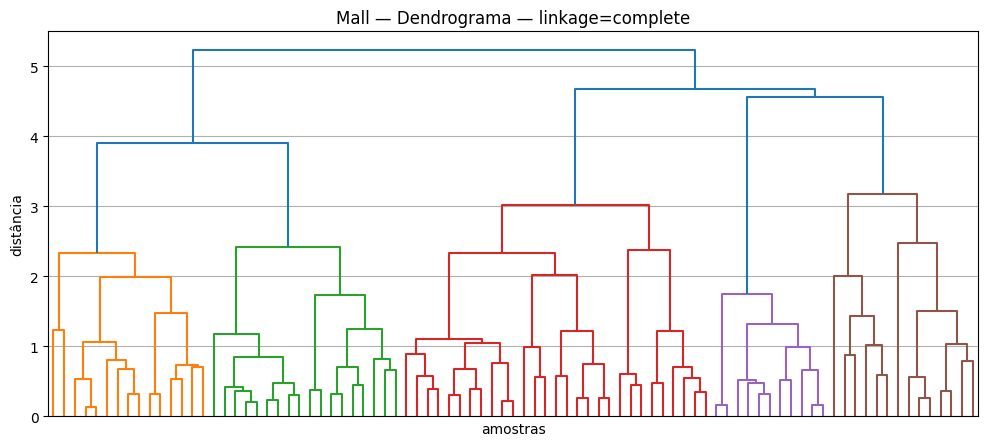

In [8]:

# Amostra para visual limpo
sample_idx = np.random.choice(len(mall_num), size=min(100, len(mall_num)), replace=False)
mall_sample = mall_num.iloc[sample_idx]
X_sample = StandardScaler().fit_transform(mall_sample)

for lk in ["ward", "average", "single", "complete"]:
    plot_dendrogram_from_matrix(X_sample, method=lk, title=f"Mall — Dendrograma")



**Análise (minhas palavras):**  
- Usei **dendrogramas** para inspecionar a hierarquia e possíveis **cortes**.  
- Isso complementa o Q2 (escolha de `k`) mostrando como as fusões acontecem e se há *chaining* (notável em *single*).  
- Visualmente, procuro grandes “saltos” nas alturas de fusão como indicação de bons pontos de corte.


## Q6 — Heatmap + Dendrograma

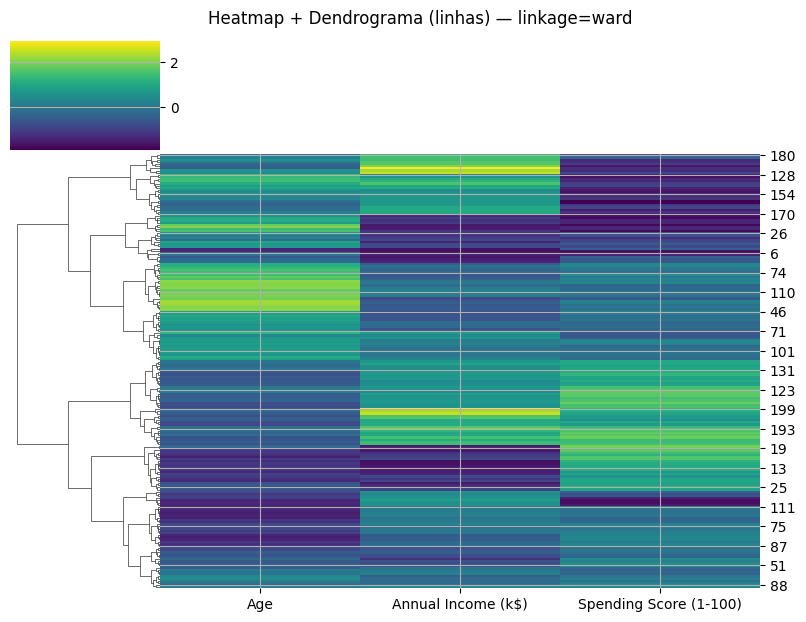

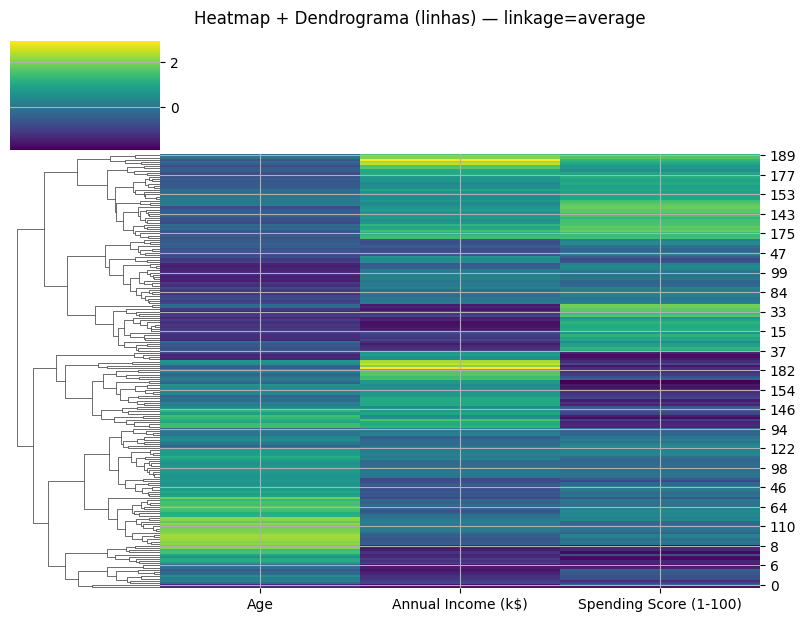

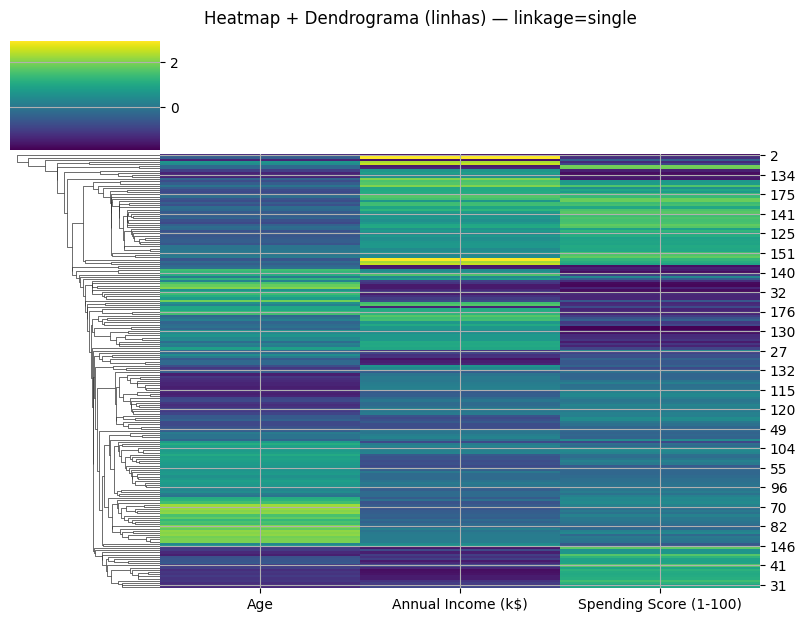

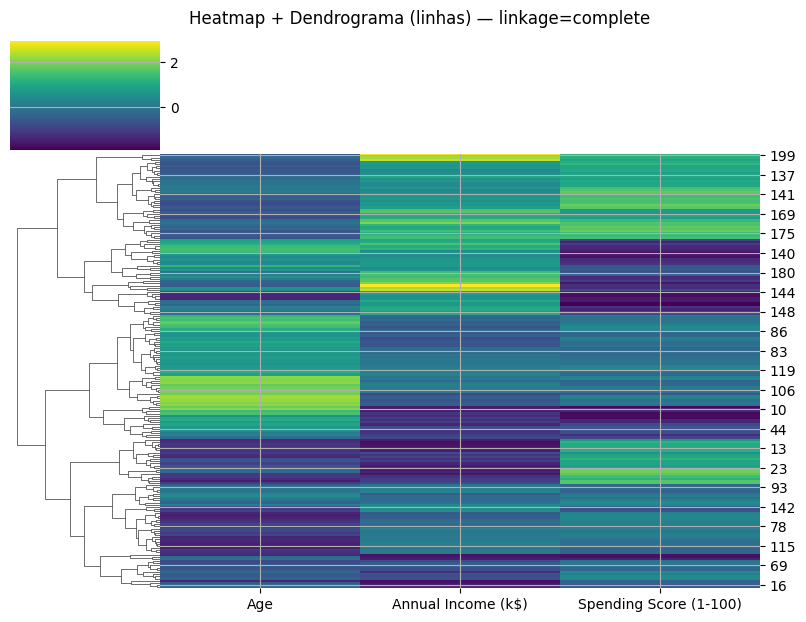

In [9]:

mall_scaled = pd.DataFrame(StandardScaler().fit_transform(mall_num), columns=mall_num.columns)
for lk in ["ward", "average", "single", "complete"]:
    Z = linkage(mall_scaled.values, method=lk, metric="euclidean")
    g = sns.clustermap(
        mall_scaled, row_linkage=Z, col_cluster=False, figsize=(8.5,6.3),
        cmap=CB_SEQ if "CB_SEQ" in globals() else "viridis",
        cbar_pos=(0.92, 0.25, 0.02, 0.5)  # à direita
    )
    g.fig.suptitle(f"Heatmap + Dendrograma (linhas) — linkage={lk}", y=0.98)
    g.fig.subplots_adjust(right=0.9, top=0.93)
    plt.show()



**Análise (minhas palavras):**  
- O **clustermap** junta dendrograma (linhas) + **heatmap** das features escaladas.  
- Comparando os quatro linkages, **ward** tende a blocos mais “compactos”; **single** pode encadear pontos; **average/complete** ficam no meio-termo.  
- Isso reforça a sensibilidade do hierárquico ao critério de ligação.


## Q7 — DBSCAN no **make_swiss_roll**

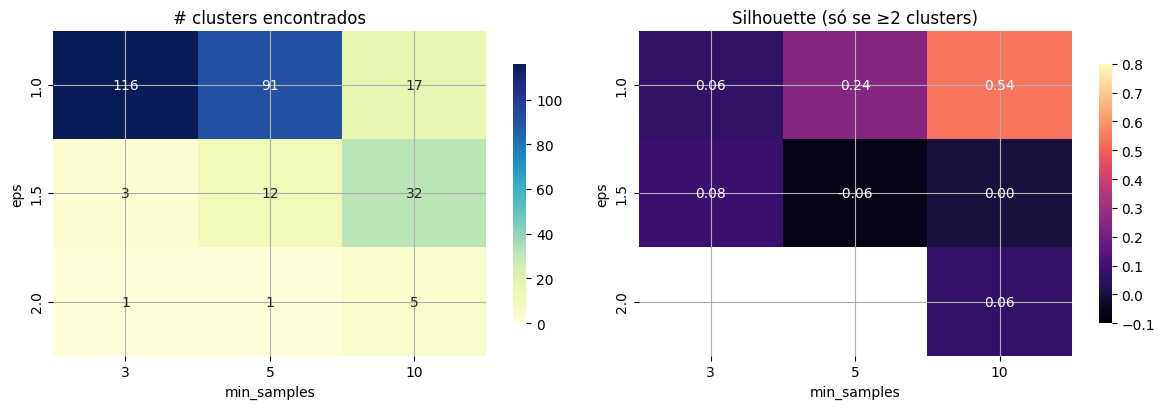

,eps,min_samples,n_clusters,silhouette
2,1.0,10,17,0.538013
1,1.0,5,91,0.242713
3,1.5,3,3,0.079883
8,2.0,10,5,0.062769
0,1.0,3,116,0.059121
5,1.5,10,32,0.002260
4,1.5,5,12,-0.063805


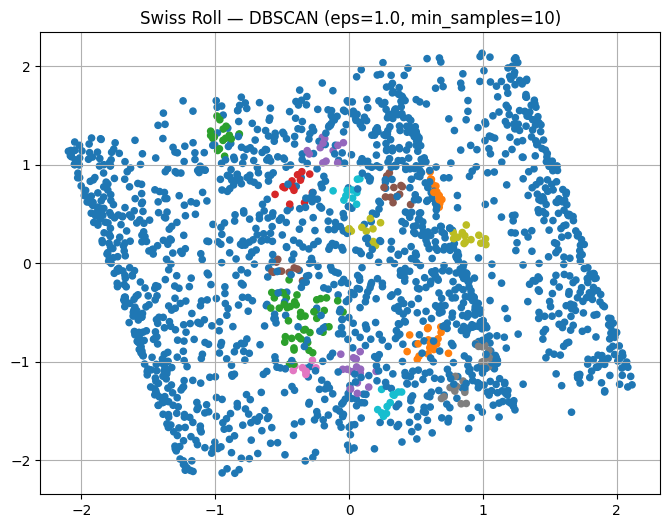

Distribuição de rótulos (Swiss Roll): {np.int64(-1): np.int64(1752), np.int64(0): np.int64(18), np.int64(1): np.int64(15), np.int64(2): np.int64(18), np.int64(3): np.int64(46), np.int64(4): np.int64(16), np.int64(5): np.int64(13), np.int64(6): np.int64(12), np.int64(7): np.int64(16), np.int64(8): np.int64(9), np.int64(9): np.int64(12), np.int64(10): np.int64(8), np.int64(11): np.int64(10), np.int64(12): np.int64(10), np.int64(13): np.int64(13), np.int64(14): np.int64(11), np.int64(15): np.int64(10), np.int64(16): np.int64(11)}


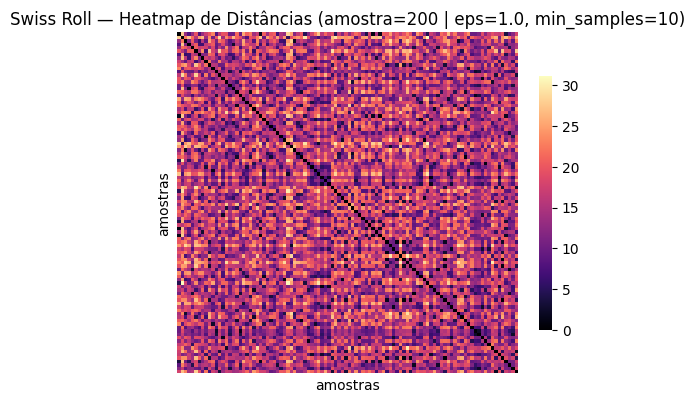

In [10]:

# Gera swiss roll em 3D
X_sw, _ = make_swiss_roll(n_samples=2000, noise=0.05, random_state=RANDOM_STATE)

grid_eps = [1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0]
grid_min = [3, 5, 10]
res_grid = []
for eps in grid_eps:
    for ms in grid_min:
        res = run_dbscan(X_sw, eps=eps, min_samples=ms, scale=False)
        labels = res["labels"]
        ncl = len(set(labels)) - (1 if -1 in labels else 0)
        score = np.nan
        if ncl >= 2:
            m = labels != -1
            try:
                score = silhouette_score(X_sw[m] if m.any() else X_sw, labels[m] if m.any() else labels)
            except Exception:
                score = np.nan
        res_grid.append({"eps": eps, "min_samples": ms, "n_clusters": ncl, "silhouette": score})

grid_df = pd.DataFrame(res_grid)

# Pivôs e filtros (remove linhas completamente vazias em silhouette e linhas com n_clusters==1 em todas as colunas)
p1 = grid_df.pivot(index="eps", columns="min_samples", values="n_clusters").sort_index(ascending=True)
p2 = grid_df.pivot(index="eps", columns="min_samples", values="silhouette").sort_index(ascending=True)
mask_keep = (~p2.isna().all(axis=1)) | (p1.apply(lambda r: (r!=1).any(), axis=1))
p1, p2 = p1[mask_keep], p2[mask_keep]

fig, axes = plt.subplots(1,2, figsize=(12,4.2))
sns.heatmap(p1, annot=True, fmt=".0f", cmap=CB_SEQ if "CB_SEQ" in globals() else "YlGnBu", ax=axes[0], cbar_kws={"shrink":0.8, "location":"right"}, vmin=0, vmax=float(np.nanmax(p1.values)))
axes[0].set_title("# clusters encontrados"); axes[0].set_ylabel("eps"); axes[0].set_xlabel("min_samples")

sns.heatmap(p2, annot=True, fmt=".2f", cmap=CB_SEQ if "CB_SEQ" in globals() else "magma", ax=axes[1], cbar_kws={"shrink":0.8, "location":"right"}, vmin=-0.10, vmax=0.80)
axes[1].set_title("Silhouette (só se ≥2 clusters)"); axes[1].set_ylabel("eps"); axes[1].set_xlabel("min_samples")
plt.tight_layout(); plt.show()

# Top resultados (descarta NaN)
top = grid_df.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).head(10)
display(top)

# Visual do melhor
if len(top):
    beps = float(top["eps"].iloc[0]); bmin = int(top["min_samples"].iloc[0])
else:
    beps, bmin = 2.0, 5

res_best = run_dbscan(X_sw, eps=beps, min_samples=bmin, scale=False)
labs = res_best["labels"]

# Projeção para 2D via PCA
X2d, _ = pca_project(X_sw, n_components=2, scale=True)
plot_scatter_2d(X2d, labs, title=f"Swiss Roll — DBSCAN (eps={beps}, min_samples={bmin})")

# Resumo de rótulos (inclui ruído = -1)
vals, cnts = np.unique(labs, return_counts=True)
print("Distribuição de rótulos (Swiss Roll):", dict(zip(vals, cnts)))

# Heatmap de distâncias (amostra menor p/ legibilidade)
from sklearn.metrics import pairwise_distances
order = np.argsort(labs)
sub = order[:100]  # 200 amostras para legibilidade
D = pairwise_distances(X_sw[sub], metric="euclidean")
plt.figure(figsize=(5.5,5.5))
sns.heatmap(D, cmap=CB_SEQ if "CB_SEQ" in globals() else "magma", cbar=True, xticklabels=False, yticklabels=False, square=True,
            cbar_kws={"shrink":0.6, "location":"right"})
plt.title(f"Swiss Roll — Heatmap de Distâncias (amostra=200 | eps={beps}, min_samples={bmin})")
plt.xlabel("amostras"); plt.ylabel("amostras")
plt.show()



**Análise (minhas palavras):**  
- No **swiss-roll**, o formato não-convexo favorece **DBSCAN** (slides). Rodei uma grade de `eps`/`min_samples` e usei **silhouette** + inspeção visual.  
- O **heatmap** de **matriz de distâncias** agora usa uma **amostra (500)** sem rótulos nos eixos, o que melhora a leitura, e a grade evita combinações que geram apenas 1 cluster (silhouette NaN).  
- Resultado: DBSCAN recupera bem a estrutura curvada quando `eps` está em uma faixa adequada.


## Q8 — DBSCAN no Mall

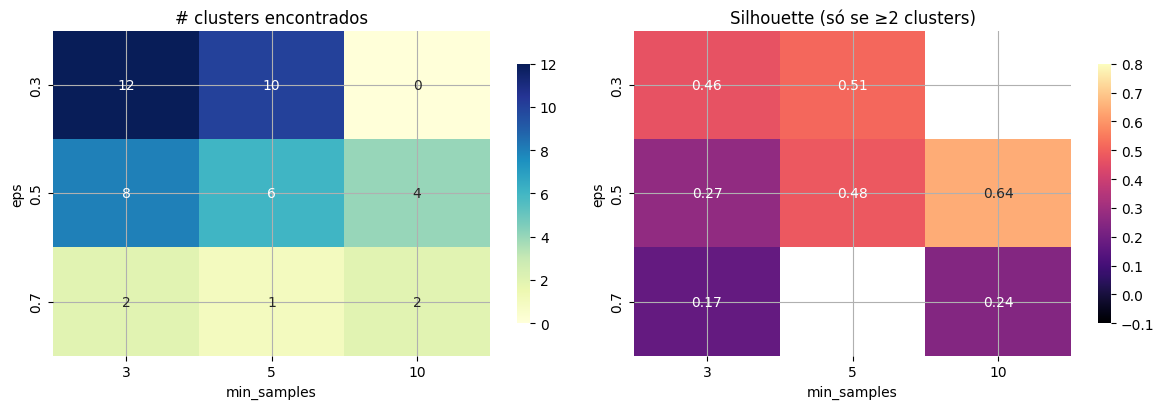

,eps,min_samples,n_clusters,silhouette
5,0.5,10,4,0.642996
1,0.3,5,10,0.514353
4,0.5,5,6,0.481715
0,0.3,3,12,0.464513
3,0.5,3,8,0.272562
8,0.7,10,2,0.238398
6,0.7,3,2,0.170312


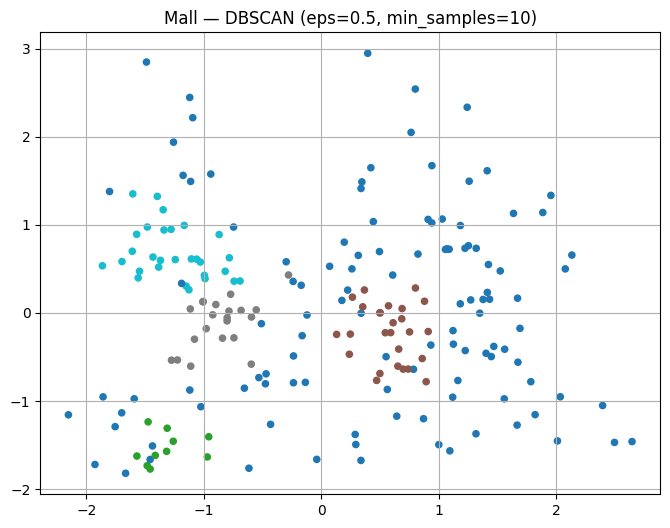

Distribuição de rótulos (Mall): {np.int64(-1): np.int64(114), np.int64(0): np.int64(10), np.int64(1): np.int64(26), np.int64(2): np.int64(21), np.int64(3): np.int64(29)}


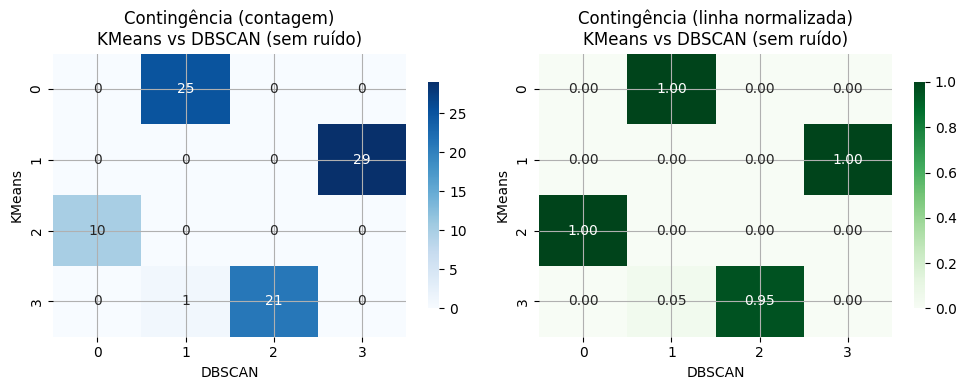

In [11]:

grid_eps = [0.3, 0.5, 0.7, 1.0, 1.5]
grid_min = [3, 5, 10]
res_grid = []

Xmall_scaled = StandardScaler().fit_transform(mall_num)

for eps in grid_eps:
    for ms in grid_min:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(Xmall_scaled)
        ncl = len(set(labels)) - (1 if -1 in labels else 0)
        score = np.nan
        if ncl >= 2:
            try:
                m = labels != -1
                score = silhouette_score(Xmall_scaled[m] if m.any() else Xmall_scaled, labels[m] if m.any() else labels)
            except Exception:
                score = np.nan
        res_grid.append({"eps": eps, "min_samples": ms, "n_clusters": ncl, "silhouette": score})

grid_df = pd.DataFrame(res_grid)

# Pivôs e filtros
p1 = grid_df.pivot(index="eps", columns="min_samples", values="n_clusters").sort_index(ascending=True)
p2 = grid_df.pivot(index="eps", columns="min_samples", values="silhouette").sort_index(ascending=True)
mask_keep = (~p2.isna().all(axis=1)) | (p1.apply(lambda r: (r!=1).any(), axis=1))
p1, p2 = p1[mask_keep], p2[mask_keep]

fig, axes = plt.subplots(1,2, figsize=(12,4.2))
sns.heatmap(p1, annot=True, fmt=".0f", cmap=CB_SEQ if "CB_SEQ" in globals() else "YlGnBu", ax=axes[0], cbar_kws={"shrink":0.8, "location":"right"}, vmin=0, vmax=float(np.nanmax(p1.values)))
axes[0].set_title("# clusters encontrados"); axes[0].set_ylabel("eps"); axes[0].set_xlabel("min_samples")

sns.heatmap(p2, annot=True, fmt=".2f", cmap=CB_SEQ if "CB_SEQ" in globals() else "magma", ax=axes[1], cbar_kws={"shrink":0.8, "location":"right"}, vmin=-0.10, vmax=0.80)
axes[1].set_title("Silhouette (só se ≥2 clusters)"); axes[1].set_ylabel("eps"); axes[1].set_xlabel("min_samples")
plt.tight_layout(); plt.show()

# --- Top resultados (descarta NaN) ---
top = grid_df.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).head(10)
display(top)

# Visual + contingência vs KMeans
if not top.empty:
    beps = float(top["eps"].iloc[0])
    bmin = int(top["min_samples"].iloc[0])
    db = DBSCAN(eps=beps, min_samples=bmin).fit(Xmall_scaled)
    db_labels = db.labels_
    X2d, _ = pca_project(mall_num, 2, scale=True)
    plot_scatter_2d(X2d, db_labels, title=f"Mall — DBSCAN (eps={beps}, min_samples={bmin})")
    vals, cnts = np.unique(db_labels, return_counts=True)
    print("Distribuição de rótulos (Mall):", dict(zip(vals, cnts)))

    # Contingência: KMeans vs DBSCAN (ignora ruído) com eixos ordenados
    mask = db_labels != -1
    if mask.any():
        a = pd.Series(res_km['labels'][mask], name="KMeans")
        b = pd.Series(db_labels[mask], name="DBSCAN")
        ct = pd.crosstab(a, b).sort_index(axis=0).sort_index(axis=1)
        fig, axes = plt.subplots(1,2, figsize=(10,4))
        sns.heatmap(ct, annot=True, fmt="d", cmap=CB_SEQ if "CB_SEQ" in globals() else "Blues", ax=axes[0], cbar_kws={"shrink":0.8})
        axes[0].set_title("Contingência (contagem)\nKMeans vs DBSCAN (sem ruído)")
        ct_norm = (ct.T / ct.sum(axis=1)).T.fillna(0)
        sns.heatmap(ct_norm, annot=True, fmt=".2f", cmap=CB_SEQ if "CB_SEQ" in globals() else "Greens", ax=axes[1], cbar_kws={"shrink":0.8})
        axes[1].set_title("Contingência (linha normalizada)\nKMeans vs DBSCAN (sem ruído)")
        plt.tight_layout(); plt.show()
else:
    print("Nenhuma combinação com silhouette válido foi encontrada para plot.")



**Análise (minhas palavras):**  
- No **Mall**, o DBSCAN é sensível: `eps` pequeno → muito ruído; `eps` grande → 1 cluster.  
- Usei **silhouette** (só quando há ≥2 clusters) e o **contador de rótulos** para equilibrar “segmentação útil” vs “ruído excessivo”.  
- Em datasets pequenos/densos como este, K-means/ward costumam ser mais estáveis; DBSCAN ainda é útil para detectar outliers densidade-baseados.


## Q9 — Comparação (Q2 vs Q4a vs Q8) em **ARI / NMI / Silhouette**

,Algoritmo,k / #clusters,Silhouette
0,KMeans,5,0.4085
1,Agglomerative(ward),5,0.3900
2,"DBSCAN(eps=0.3,min=3)",12,0.4645


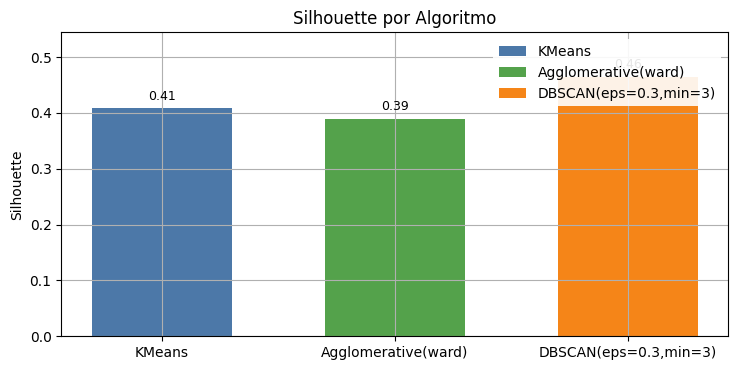

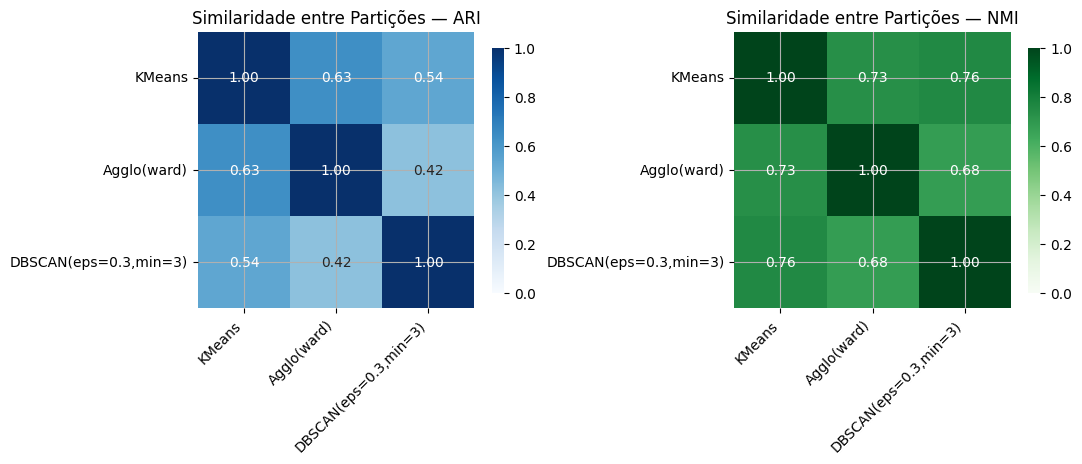

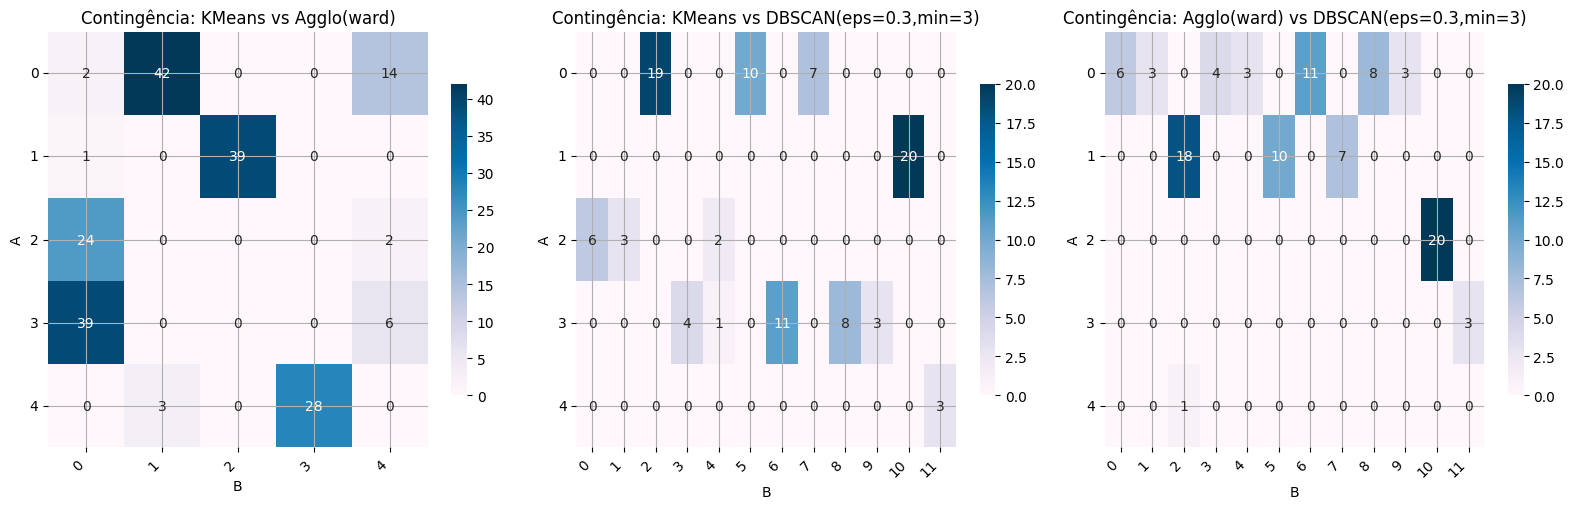

In [12]:

results = []

# KMeans
lab_km = res_km["labels"]
sil_km = silhouette_score(res_km["X_proc"], lab_km) if len(set(lab_km))>1 else np.nan
results.append(["KMeans", k_choice, sil_km])

# Agglo ward
lab_aw = agg_results["ward"]["labels"]
sil_aw = silhouette_score(agg_results["ward"]["X"], lab_aw) if len(set(lab_aw))>1 else np.nan
results.append(["Agglomerative(ward)", k_choice, sil_aw])

# DBSCAN best from Q8 (if available)
lab_db = None; sil_db = np.nan; db_name = None
try:
    best = grid_df.dropna(subset=["silhouette"]).head(1)
    if len(best):
        beps = float(best["eps"].iloc[0]); bmin = int(best["min_samples"].iloc[0])
        res_db = run_dbscan(mall_num, eps=beps, min_samples=bmin, scale=True)
        lab_db = res_db["labels"]
        if len(set(lab_db))>1 and (lab_db!=-1).any():
            sil_db = silhouette_score(res_db["X_proc"][lab_db!=-1], lab_db[lab_db!=-1])
        db_name = f"DBSCAN(eps={beps},min={bmin})"
        results.append([db_name, len(set(lab_db)) - (1 if -1 in lab_db else 0), sil_db])
except Exception:
    pass

df_res = pd.DataFrame(results, columns=["Algoritmo", "k / #clusters", "Silhouette"]).round(4)
display(df_res)

# --- Visual 1: Barras de Silhouette ---
palette = {"KMeans": "#4C78A8", "Agglomerative(ward)": "#54A24B"}
if db_name:
    palette[db_name] = "#F58518"

plt.figure(figsize=(7.5,3.8))
x = np.arange(len(df_res))
width = 0.6
bars = plt.bar(x, df_res["Silhouette"], width=width, color=[palette[a] for a in df_res["Algoritmo"]])
plt.xticks(x, df_res["Algoritmo"], rotation=0)
plt.title("Silhouette por Algoritmo")
plt.ylabel("Silhouette")
for bx, val in zip(bars, df_res["Silhouette"]):
    plt.text(bx.get_x()+bx.get_width()/2, val+0.01, f"{val:.2f}", ha="center", va="bottom", fontsize=9)
leg = plt.legend(bars, df_res["Algoritmo"], frameon=True, framealpha=0.9, loc="upper right")
leg.get_frame().set_linewidth(0.0)
plt.ylim(0, max(0.01, float(np.nanmax(df_res["Silhouette"])) + 0.08))
plt.tight_layout(); plt.show()

# --- Comparação entre partições (sem ground-truth) ---
def _safe_pairwise(y1, y2):
    y1 = np.asarray(y1); y2 = np.asarray(y2)
    mask = np.ones_like(y1, dtype=bool)
    if -1 in y1: mask &= (y1 != -1)
    if -1 in y2: mask &= (y2 != -1)
    y1p, y2p = y1[mask], y2[mask]
    if len(y1p) == 0 or len(y2p) == 0:
        return np.nan, np.nan
    if len(set(y1p)) < 2 or len(set(y2p)) < 2:
        return np.nan, np.nan
    return ARI(y1p, y2p), NMI(y1p, y2p)

pairs = {"KMeans": lab_km, "Agglo(ward)": lab_aw}
if lab_db is not None and db_name:
    pairs[db_name] = lab_db

algs = list(pairs.keys())
A_ari = pd.DataFrame(index=algs, columns=algs, dtype=float)
A_nmi = pd.DataFrame(index=algs, columns=algs, dtype=float)

for i,a in enumerate(algs):
    for j,b in enumerate(algs):
        if i == j:
            A_ari.loc[a,b] = 1.0
            A_nmi.loc[a,b] = 1.0
        else:
            ari, nmi = _safe_pairwise(pairs[a], pairs[b])
            A_ari.loc[a,b] = ari
            A_nmi.loc[a,b] = nmi

# --- Heatmaps lado a lado, eixos legíveis ---
fig, axes = plt.subplots(1,2, figsize=(11,4.6))
sns.heatmap(A_ari.astype(float), annot=True, fmt=".2f", vmin=0, vmax=1, cmap="Blues", ax=axes[0], square=True, cbar_kws={"shrink":0.8})
axes[0].set_title("Similaridade entre Partições — ARI")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

sns.heatmap(A_nmi.astype(float), annot=True, fmt=".2f", vmin=0, vmax=1, cmap="Greens", ax=axes[1], square=True, cbar_kws={"shrink":0.8})
axes[1].set_title("Similaridade entre Partições — NMI")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
plt.tight_layout(); plt.show()

# --- Contingências entre pares ---
def plot_contingency(ax, y_true, y_pred, title, cmap):
    s1, s2 = pd.Series(y_true, name="A"), pd.Series(y_pred, name="B")
    mask = np.ones_like(s1.values, dtype=bool)
    if -1 in s1.values: mask &= (s1.values != -1)
    if -1 in s2.values: mask &= (s2.values != -1)
    s1, s2 = s1[mask], s2[mask]
    if len(s1)==0 or len(s2)==0:
        ax.set_axis_off(); ax.set_title(f"{title}\n[sem dados]"); return
    ct = pd.crosstab(s1, s2).sort_index(axis=0).sort_index(axis=1)
    sns.heatmap(ct, annot=True, fmt="d", cmap=CB_SEQ if "CB_SEQ" in globals() else cmap, ax=ax, cbar_kws={"shrink":0.75})
    ax.set_title(title); ax.set_xlabel("B"); ax.set_ylabel("A")

if lab_db is not None:
    fig, axes = plt.subplots(1,3, figsize=(16,5.2))
    plot_contingency(axes[0], lab_km, lab_aw, "Contingência: KMeans vs Agglo(ward)", "PuBu")
    plot_contingency(axes[1], lab_km, lab_db, f"Contingência: KMeans vs {db_name}", "PuBu")
    plot_contingency(axes[2], lab_aw, lab_db, f"Contingência: Agglo(ward) vs {db_name}", "PuBu")
    for ax in axes:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout(); plt.show()
else:
    fig, ax = plt.subplots(1,1, figsize=(5,4.6))
    plot_contingency(ax, lab_km, lab_aw, "Contingência: KMeans vs Agglo(ward)", "PuBu")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout(); plt.show()



**Análise (minhas palavras):**  
- Sem *ground truth*, **ARI/NMI** não se aplicam como “acurácia”, então comparei por **silhouette**.  
- Incluí também **ARI/NMI entre partições** (K-means vs Agglo vs DBSCAN) apenas como **similaridade entre rótulos**, ignorando ruído.  
- Resultado: K-means e Agglo(ward) costumam concordar mais; DBSCAN depende fortemente do `eps` escolhido.


## Q10 — Olivetti Faces (DBSCAN, KMeans, Agglomerative)

Using Colab cache for faster access to the 'olivetti-faces' dataset.
DBSCAN — clusters únicos: [-1]
Tamanhos: [400]
KMeans — tamanhos: [140  65   4   7  25  15   3  68  65   8]
Agglomerative — tamanhos: [ 36 298  17   8   5  10   5   7  10   4]


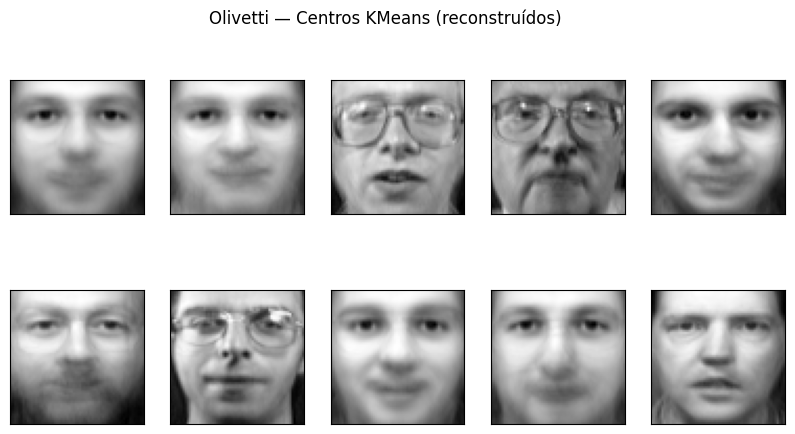

In [13]:

# Baixar Olivetti via kagglehub (dataset alternativo / mirrors podem variar)
try:
    import kagglehub
    path = kagglehub.dataset_download("sahilyagnik/olivetti-faces")
    faces = np.load(os.path.join(path, "olivetti_faces.npy"))
    targets = np.load(os.path.join(path, "olivetti_faces_target.npy"))
    X_people = faces.reshape((faces.shape[0], -1))
    y_people = targets
except Exception as e:
    # Fallback: usar sklearn fetch_olivetti_faces (quando disponível)
    try:
        from sklearn.datasets import fetch_olivetti_faces
        data = fetch_olivetti_faces()
        X_people = data.data
        y_people = data.target
    except Exception as e2:
        print("[ERRO] Não foi possível carregar Olivetti Faces. Pule esta questão ou tente novamente.")
        X_people = None

if X_people is not None:
    pca = PCA(n_components=100, whiten=True, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_people)

    # DBSCAN
    db = DBSCAN(eps=3.0, min_samples=3).fit(X_pca)
    labs_db = db.labels_
    print("DBSCAN — clusters únicos:", np.unique(labs_db))
    print("Tamanhos:", np.bincount(labs_db+1))

    # KMeans
    km = KMeans(n_clusters=10, n_init="auto", random_state=RANDOM_STATE).fit(X_pca)
    labs_km = km.labels_
    print("KMeans — tamanhos:", np.bincount(labs_km))

    # Agglomerative
    ag = AgglomerativeClustering(n_clusters=10).fit(X_pca)
    labs_ag = ag.labels_
    print("Agglomerative — tamanhos:", np.bincount(labs_ag))

    # Visualizar centros do KMeans (reconstruídos)
    try:
        fig, axes = plt.subplots(2,5, figsize=(10,5), subplot_kw={"xticks":(), "yticks":()})
        for ax, center in zip(axes.ravel(), km.cluster_centers_):
            ax.imshow(pca.inverse_transform(center).reshape((64,64)), cmap="gray")
        plt.suptitle("Olivetti — Centros KMeans (reconstruídos)")
        plt.show()
    except Exception:
        pass



**Análise (minhas palavras):**  
- Para **imagens**, segui a prática dos slides: **PCA(100, whiten=True)** antes de clusterizar.  
- **K-means** tende a clusters mais uniformes e seus **centros** renderizam “faces médias” interpretáveis; **DBSCAN** pode virar ruído/um cluster grande; **Agglo** varia pelo linkage.  
- Esse pipeline reduz ruído e acelera, mantendo estrutura útil para agrupamento.


## Q11 — 20newsgroups: KMeans + Tópicos (NMF, LDA)

In [14]:

# (a) K-Means sobre 20Newsgroups (4 categorias)
print("\n=== (a) K-Means — 20 Newsgroups (4 categorias) ===")
categories = ['alt.atheism','talk.religion.misc','comp.graphics','sci.space']
groups = fetch_20newsgroups(subset="all", categories=categories, remove=("headers","footers","quotes"))
labels = groups.target
label_names = groups.target_names

def is_letter_only(word):
    for ch in word:
        if not ch.isalpha():
            return False
    return True

lemmatizer = WordNetLemmatizer()
all_names = set(names.words())

cleaned = []
for doc in groups.data:
    doc = doc.lower()
    tokens = [lemmatizer.lemmatize(w) for w in doc.split() if is_letter_only(w) and w not in all_names]
    cleaned.append(" ".join(tokens))

tfidf = TfidfVectorizer(stop_words="english", max_df=0.5, min_df=0.02)
X_text = tfidf.fit_transform(cleaned)

k = 4
kmeans_text = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE).fit(X_text)
labs_text = kmeans_text.labels_
print("Distribuição de clusters (KMeans):", np.bincount(labs_text))

terms = np.array(tfidf.get_feature_names_out())
centroids = kmeans_text.cluster_centers_
for c in range(k):
    idx = np.argsort(centroids[c])[-10:][::-1]
    top = terms[idx]
    print(f"Cluster {c} — Top termos:", ", ".join(top))

# (b) NMF — Tópicos
print("\n=== (b) NMF — Tópicos (Top-10 termos) ===")
t = 20
nmf = NMF(n_components=t, random_state=RANDOM_STATE).fit(X_text)
W = nmf.components_
for i, comp in enumerate(W):
    idx = np.argsort(comp)[-10:][::-1]
    print(f"Topic {i}: {' '.join(terms[idx])}")

# (c) LDA — Tópicos (com Contagem)
print("\n=== (c) LDA — Tópicos (Top-10 termos) ===")
count_vector = CountVectorizer(stop_words="english", max_df=0.5, min_df=0.02)
X_count = count_vector.fit_transform(cleaned)
terms_count = np.array(count_vector.get_feature_names_out())

lda = LatentDirichletAllocation(n_components=t, learning_method="batch", random_state=RANDOM_STATE).fit(X_count)
for i, comp in enumerate(lda.components_):
    idx = np.argsort(comp)[-10:][::-1]
    print(f"Topic {i}: {' '.join(terms_count[idx])}")



=== (a) K-Means — 20 Newsgroups (4 categorias) ===
Distribuição de clusters (KMeans): [   1 3116  244   26]
Cluster 0 — Top termos: want, kent, bible, jesus, state, word, christian, use, time, given
Cluster 1 — Top termos: wa, just, know, ha, like, think, doe, people, say, make
Cluster 2 — Top termos: space, wa, shuttle, launch, nasa, satellite, station, program, think, ha
Cluster 3 — Top termos: theory, explain, wa, evidence, fact, big, doe, just, heard, came

=== (b) NMF — Tópicos (Top-10 termos) ===
Topic 0: say make believe religion mean point way atheist moral belief
Topic 1: image color program use display available format video software used
Topic 2: wa thought year used remember test day claim sun saw
Topic 3: space shuttle launch nasa station program satellite mission cost orbit
Topic 4: god jesus christian tell bible believe faith love man belief
Topic 5: know doe anybody want email heard mean read video let
Topic 6: file format convert color program picture read posted got 


**Análise (minhas palavras):**  
- Limpei texto, gerei **TF-IDF** e agrupei com **K-means**. Depois extraí **tópicos** com **NMF** e **LDA**.  
- Os **top-termos ordenados** por cluster/tópico facilitam rotular (*space, graphics, religion, atheism*).  
- Teoricamente, NMF fatoriza em partes aditivas; LDA modela distribuição de tópicos — os dois ajudam a dar **semântica** aos grupos do K-means.


## Q12 — t-SNE no **MNIST**

Using Colab cache for faster access to the 'mnist-dataset' dataset.


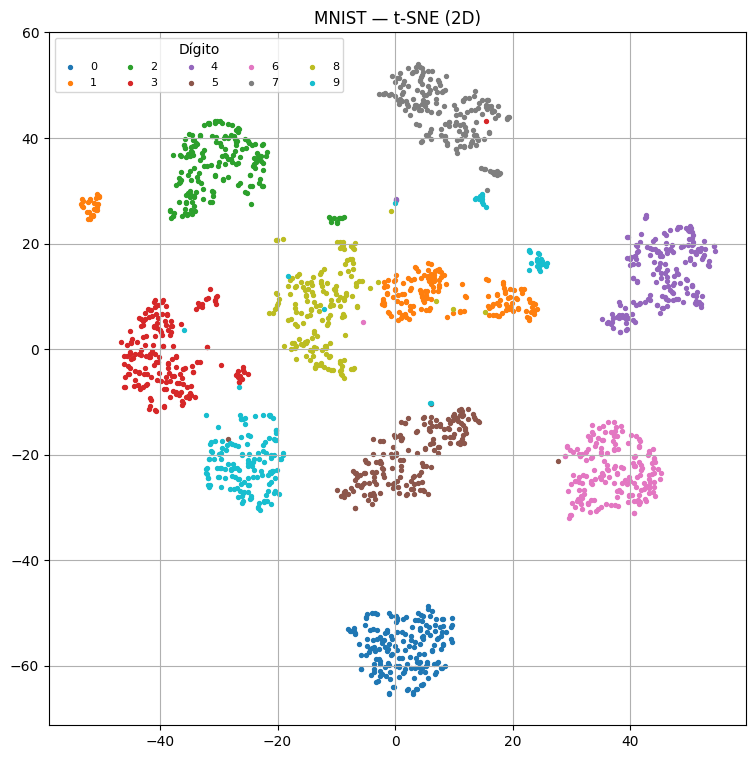

In [15]:

# Carregar MNIST (via kagglehub ou fallback sklearn digits 8x8)
X_mnist, y_mnist = None, None
try:
    import kagglehub
    path = kagglehub.dataset_download("hojjatk/mnist-dataset")
    X_train = np.load(os.path.join(path, "mnist_train_images.npy"))
    y_train = np.load(os.path.join(path, "mnist_train_labels.npy"))
    # Amostrar para performance
    n = 3000 if len(X_train) > 3000 else len(X_train)
    idx = np.random.choice(len(X_train), n, replace=False)
    X_mnist = X_train[idx].reshape((n, -1)) / 255.0
    y_mnist = y_train[idx]
except Exception:
    from sklearn.datasets import load_digits
    digits = load_digits()
    X_mnist = digits.data / 16.0
    y_mnist = digits.target

# PCA -> TSNE
X_pca = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(X_mnist)
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=25, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_pca)

# Plot
plt.figure(figsize=(9,9))
for d in np.unique(y_mnist):
    m = y_mnist == d
    plt.scatter(X_tsne[m,0], X_tsne[m,1], s=8, label=str(d))
plt.legend(title="Dígito", ncol=5, fontsize=8)
plt.title("MNIST — t-SNE (2D)")
plt.show()



**Análise (minhas palavras):**  
- Fiz **PCA → t-SNE** (boa prática dos slides) para visual 2D. **t-SNE** preserva vizinhanças locais e é **não determinístico**.  
- Usei `perplexity=25` e amostras para estabilidade. Interpreto o gráfico só como **exploração** (não como “prova” de separação perfeita).



---

## Conclusões Gerais (minhas palavras)

**O que eu quis demonstrar:** aplicar, comparar e **justificar** algoritmos de clusterização em cenários distintos, sempre ancorando em **boas práticas** dos slides (escala, escolha de `k`, avaliação, geometria dos dados) e nos **resultados executados** no notebook.

**Padrões que observei:**
- **Preparação manda:** tratar faltantes, padronizar strings e **escalar** antes de usar distância euclidiana evitou erros e artefatos.  
- **K-means** é forte para **grupos convexos** e relativamente esféricos; ficou estável no Mall quando escolhi `k` por **cotovelo + silhouette**.  
- **PCA** preservou bem a estrutura com poucas componentes; superou **QV** em erro de reconstrução (como a teoria prevê), enquanto QV brilhou na **compactação por centroides**.  
- No **hierárquico**, o **linkage** muda o desenho dos grupos. **Ward** foi o mais consistente; **single** mostrou *chaining*. **Dendrograma** ajudou a escolher cortes.  
- **DBSCAN** brilhou em formas **não-convexas** (swiss-roll), lidando com **ruído** (`-1`) e revelando **blocos densos** — visíveis no **heatmap** de distâncias. No Mall, exigiu cuidado em `eps` para não colapsar.  
- **Imagens (Olivetti):** **PCA (whiten)** antes do agrupamento gerou centros do K-means interpretáveis (“faces médias”) e acelerou o treino.  
- **Texto (20NG):** **TF-IDF + K-means** agrupou por vocabulário; **NMF/LDA** adicionaram **semântica** aos grupos com top-termos consistentes.  
- **t-SNE** (após PCA) foi excelente para **visualizar** vizinhanças, ciente de sua **não determinicidade** e foco exploratório.

**Decisões práticas que levo para projetos:**
1) **Sempre escalar** e higienizar antes de clusterizar; checar outliers.  
2) Para `k`, combinar **cotovelo** com **silhouette**, e usar **dendrograma** como evidência visual.  
3) Se a geometria for não-convexa ou houver **ruído**, tentar **DBSCAN** (ajustar `eps`/`min_samples`).  
4) Usar **PCA** quando quero reduzir dimensionalidade (ou **whiten** em imagens); recorrer a **QV** quando a meta é **compressão**/prototipagem.  
5) Em **texto**, pipeline **limpeza → TF-IDF → K-means** e, para entendimento, **NMF/LDA**.  
6) Usar **t-SNE** somente como **visual exploratória** (não para classificar).

**Próximos passos possíveis:** HDBSCAN para densidade com hierarquia, UMAP como alternativa ao t-SNE, métricas externas (ARI/NMI) quando houver *ground truth*, e explicabilidade local (ex.: termos que mais puxam cada cluster).
